In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nabihazahid/loan-prediction-dataset-2025/loan_dataset_20000.csv


✓ Dataset successfully loaded!

--- Dataset Shape ---
(20000, 22)

--- Column Names ---
['age', 'gender', 'marital_status', 'education_level', 'annual_income', 'monthly_income', 'employment_status', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate', 'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']

--- First 3 Rows ---
   age  gender marital_status education_level  annual_income  monthly_income  \
0   59    Male        Married        Master's       24240.19         2020.02   
1   72  Female        Married      Bachelor's       20172.98         1681.08   
2   49  Female         Single     High School       26181.80         2181.82   

  employment_status  debt_to_income_ratio  credit_score  loan_amount  ...  \
0          Employed                 0.074           743     17173.72  ...   
1          Employed   

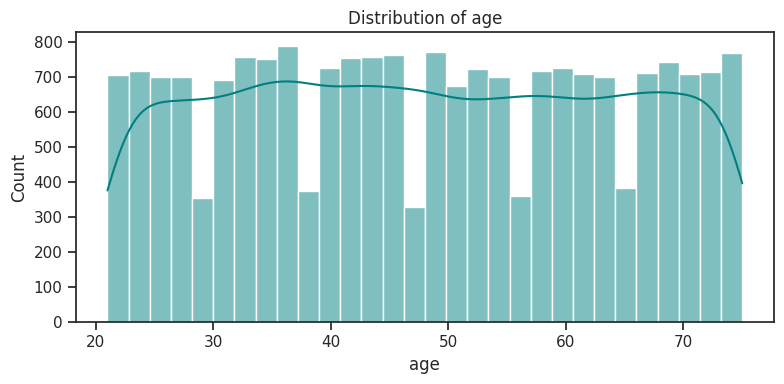

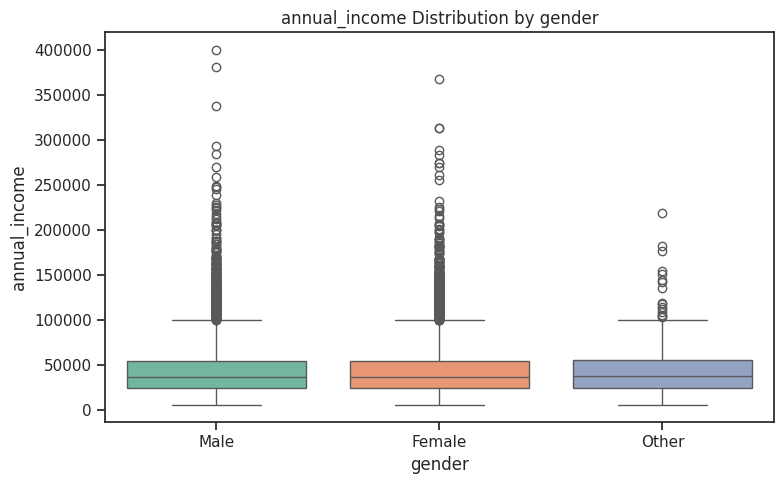

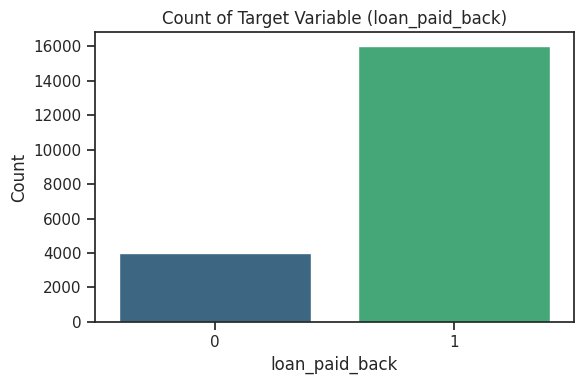


Training set size: 16000 rows
Testing set size: 4000 rows

  MODEL ACCURACY: 89.75%



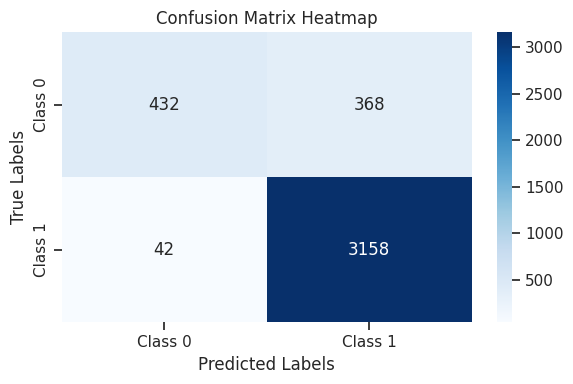

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.54      0.68       800
           1       0.90      0.99      0.94      3200

    accuracy                           0.90      4000
   macro avg       0.90      0.76      0.81      4000
weighted avg       0.90      0.90      0.89      4000



In [2]:
# =====================================================================
# TASK 2: CREDIT RISK PREDICTION (COMPLETE SOLUTION)
# =====================================================================
import warnings
warnings.filterwarnings("ignore")
# 1. Necessary Libraries Import Karna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Seaborne plots ka style set karna
sns.set_theme(style="ticks")

# =====================================================================
# 2. Data Set Load Karna (Kaggle Direct Path)
# =====================================================================
# Aapki picture ke mutabiq bilkul sahi accurate path:
file_path = "/kaggle/input/datasets/nabihazahid/loan-prediction-dataset-2025/loan_dataset_20000.csv"


try:
    df = pd.read_csv(file_path)
    print("✓ Dataset successfully loaded!")
except FileNotFoundError:
    # Backup block: Agar path me koi choti-moti spelling mistake ho to ye detect kar lega
    import os

    print("Checking available files in Kaggle input directory:")
    print(os.listdir("../input/"))
    raise FileNotFoundError(
        "File nahi mili! Kaggle panel se path copy karke check karein."
    )

# Dataset ki basic structure dekhna
print("\n--- Dataset Shape ---")
print(df.shape)
print("\n--- Column Names ---")
print(df.columns.tolist())
print("\n--- First 3 Rows ---")
print(df.head(3))

# Kaggle ke standard columns ke names ko code ke mutabiq match karna
# (Kaggle par kuch datasets me columns lowercase hote hain ya 'Loan_Status' ki jagah 'loan_status')
df.columns = [col.strip() for col in df.columns]

# Target column ka naam standard set karna (case-insensitive check)
target_col = None
for col in df.columns:
    if col.lower() in ["loan_status", "status", "default"]:
        target_col = col
        break

if target_col is None:
    # Agar column match na ho to jo aakhri column hai usko target maan lete hain
    target_col = df.columns[-1]

print(f"\nIdentified Target Column: {target_col}")

# =====================================================================
# 3. Data Cleaning & Handling Missing Values
# =====================================================================
print("\n--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# Categorical aur Numerical columns ko alag alag handle karna
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            # Categorical variables ko Mode (Most Frequent) se fill karna
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            # Numerical variables ko Median (Robust to outliers) se fill karna
            df[col].fillna(df[col].median(), inplace=True)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

# =====================================================================
# 4. Exploratory Data Analysis (EDA) - Visualizations
# =====================================================================
# Dynamic columns find karna plots ke liye taaki error na aaye
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Plot A: Income or Numerical Feature Distribution
income_feat = (
    "ApplicantIncome"
    if "ApplicantIncome" in df.columns
    else (num_cols[0] if len(num_cols) > 0 else None)
)
if income_feat:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=income_feat, kde=True, color="teal", bins=30)
    plt.title(f"Distribution of {income_feat}")
    plt.xlabel(income_feat)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Plot B: Boxplot for Loan Amount or Numeric Spread vs Education/Categorical
loan_feat = (
    "LoanAmount"
    if "LoanAmount" in df.columns
    else (num_cols[1] if len(num_cols) > 1 else num_cols[0])
)
edu_feat = (
    "Education"
    if "Education" in df.columns
    else (cat_cols[0] if len(cat_cols) > 0 else None)
)

if loan_feat and edu_feat:
    plt.figure(figsize=(8, 5))
    # 'hue' اور 'legend=False' کا اضافہ کیا گیا ہے تاکہ وارننگ ختم ہو جائے
    sns.boxplot(data=df, x=edu_feat, y=loan_feat, hue=edu_feat, palette="Set2", legend=False)
    plt.title(f"{loan_feat} Distribution by {edu_feat}")
    plt.xlabel(edu_feat)
    plt.ylabel(loan_feat)
    plt.tight_layout()
    plt.show()

# Plot C: Target variable count plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title(f"Count of Target Variable ({target_col})")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =====================================================================
# 5. Feature Encoding & Data Splitting
# =====================================================================
# ID variables ko drop karna agar mojood hon
if "Loan_ID" in df.columns:
    df.drop(columns=["Loan_ID"], inplace=True)
elif "loan_id" in df.columns:
    df.drop(columns=["loan_id"], inplace=True)

# Tamaam object/categorical columns ko label encode karna
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))

# Features (X) aur Target (y) split karna
X = df.drop(columns=[target_col])
y = df[target_col]

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

# =====================================================================
# 6. Model Training & Evaluation
# =====================================================================
# Decision Tree Classifier setup
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predictions matrix
y_pred = model.predict(X_test)

# Metrics calculation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n======================================")
print(f"  MODEL ACCURACY: {accuracy * 100:.2f}%")
print("======================================\n")

# Confusion Matrix Heatmap Plot
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0", "Class 1"],
    yticklabels=["Class 0", "Class 1"],
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))